In [ ]:
import numpy as np
import matplotlib.pyplot as plt



plt.figure(figsize=(10, 6)) # 차트 크기 -> 그래프의 가로 크기 10인치, 세로 크기 6인치
plt.xlabel('Array Size') # x축 레이블
plt.ylabel('Time') # y축 레이블
plt.title('Performance : numpy VS numpy(randint) VS random')
plt.plot(n_values, n_time, label='numpy', color='blue')
plt.plot(n_values, p_time, label='random', color='red')
plt.plot(n_values, nrand_time, label='randint', color='green')
plt.legend() # 범례를 추가
plt.grid(True) # 그래프에 그리드 ON
plt.show()

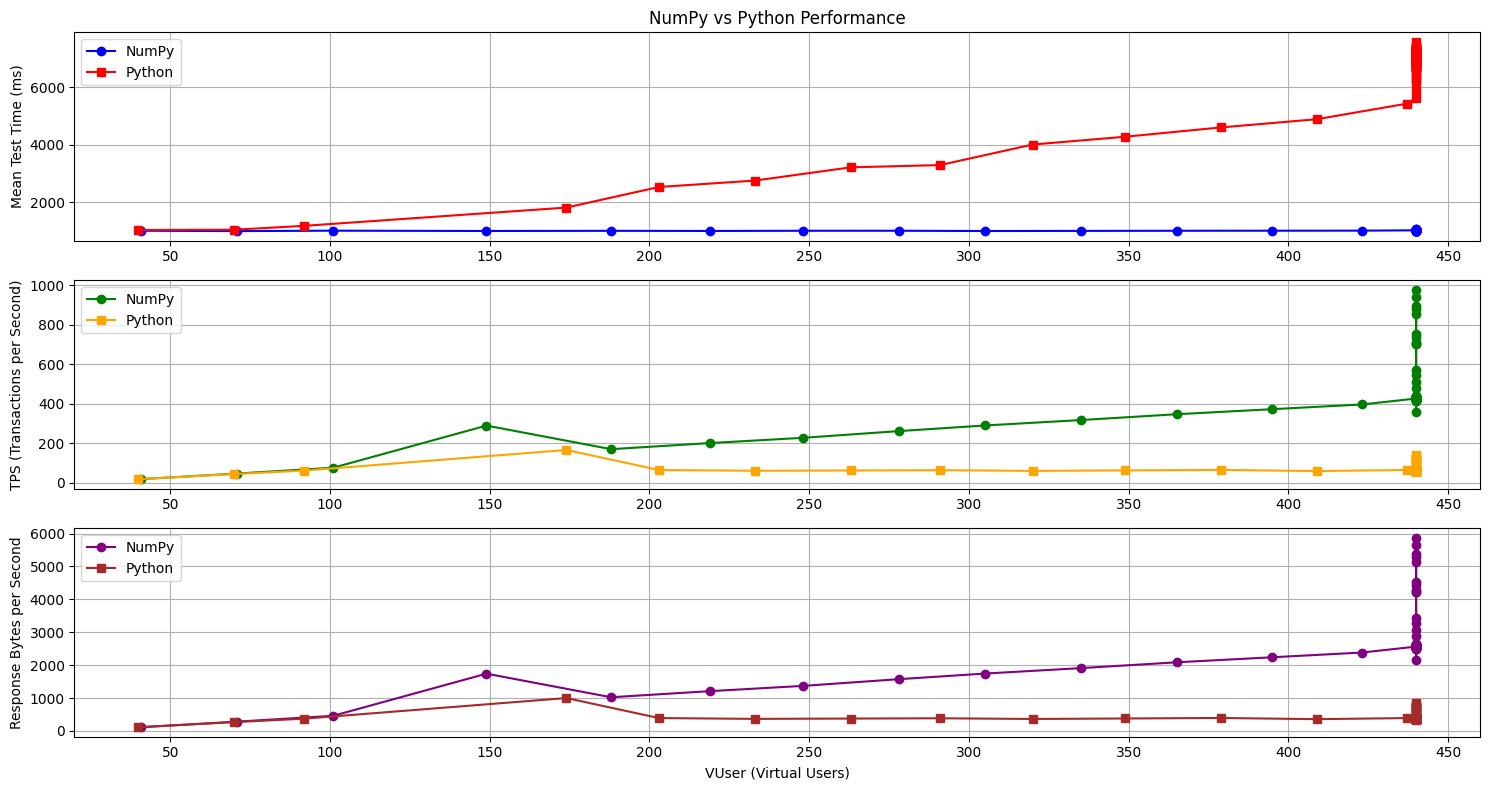

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 파일 경로
numpy_file = "nump_440.csv"
python_file = "cho_440.csv"

# 데이터 로드
df_numpy = pd.read_csv(numpy_file)
df_python = pd.read_csv(python_file)


# ✅ 필요한 컬럼 선택
x_column = "vuser"  # 가상 사용자 수 (X축)
y_column_1 = "Mean_Test_Time_(ms)"  # 평균 테스트 시간 (ms)
y_column_2 = "TPS"  # 초당 트랜잭션 수
y_column_3 = "Response_bytes_per_second"  # 응답 바이트 속도

# ✅ 그래프 설정
plt.figure(figsize=(15, 8))

# 🔹 1️⃣ Mean_Test_Time_(ms) 비교
plt.subplot(3, 1, 1)
plt.plot(df_numpy[x_column], df_numpy[y_column_1], label="NumPy", color='blue', marker='o', linestyle='-')
plt.plot(df_python[x_column], df_python[y_column_1], label="Python", color='red', marker='s', linestyle='-')
plt.ylabel("Mean Test Time (ms)")
plt.title("NumPy vs Python Performance")
plt.legend()
plt.grid(True)

# 🔹 2️⃣ TPS 비교
plt.subplot(3, 1, 2)
plt.plot(df_numpy[x_column], df_numpy[y_column_2], label="NumPy", color='green', marker='o', linestyle='-')
plt.plot(df_python[x_column], df_python[y_column_2], label="Python", color='orange', marker='s', linestyle='-')
plt.ylabel("TPS (Transactions per Second)")
plt.legend()
plt.grid(True)

# 🔹 3️⃣ Response_bytes_per_second 비교
plt.subplot(3, 1, 3)
plt.plot(df_numpy[x_column], df_numpy[y_column_3], label="NumPy", color='purple', marker='o', linestyle='-')
plt.plot(df_python[x_column], df_python[y_column_3], label="Python", color='brown', marker='s', linestyle='-')
plt.xlabel("VUser (Virtual Users)")
plt.ylabel("Response Bytes per Second")
plt.legend()
plt.grid(True)

# ✅ 그래프 출력
plt.tight_layout()
plt.show()


NumPy Data:              timestamp  vuser  tests  errors  mean_test_time_(ms)  \
0  2025-02-28 07:03:18     41     38       0             1014.500   
1  2025-02-28 07:03:20     71     94       0             1000.904   
2  2025-02-28 07:03:22    101    153       0             1015.444   
3  2025-02-28 07:03:24    149    580       0             1004.562   
4  2025-02-28 07:03:26    188    341       0             1010.663   

   test_time_standard_deviation_(ms)    tps  mean_response_length  \
0                             67.961   19.0                     6   
1                             64.443   47.0                     6   
2                             64.455   76.5                     6   
3                             66.761  290.0                     6   
4                             68.195  170.5                     6   

   response_bytes_per_second  response_errors  ...   timestamp     container  \
0                        114                0  ...  1740726182  e192d5341051  

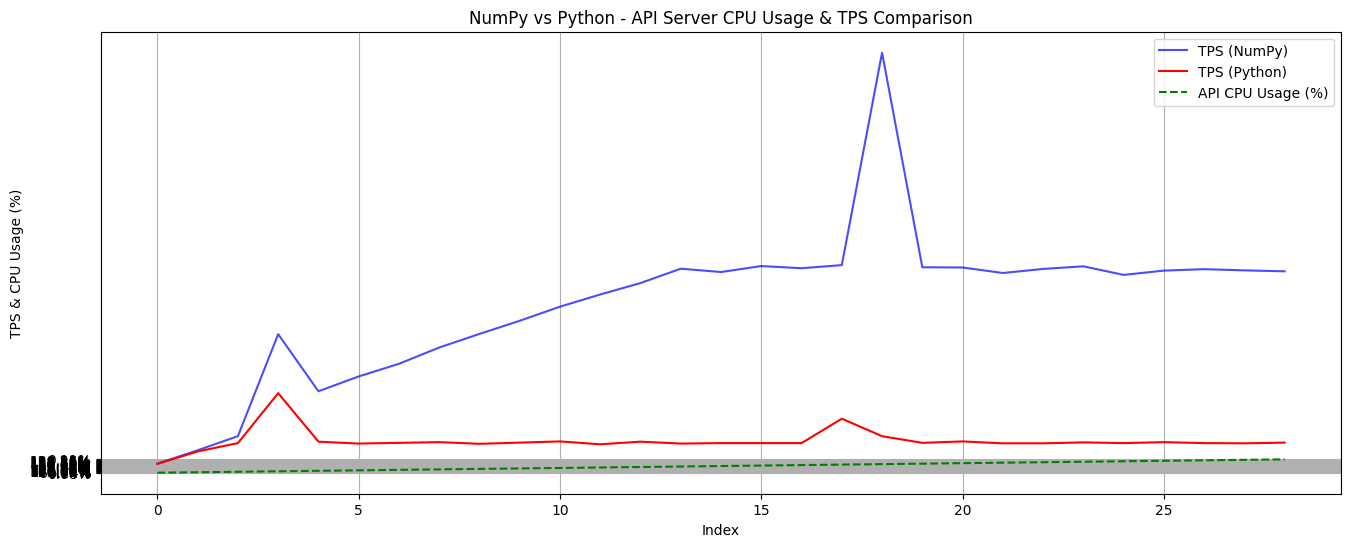

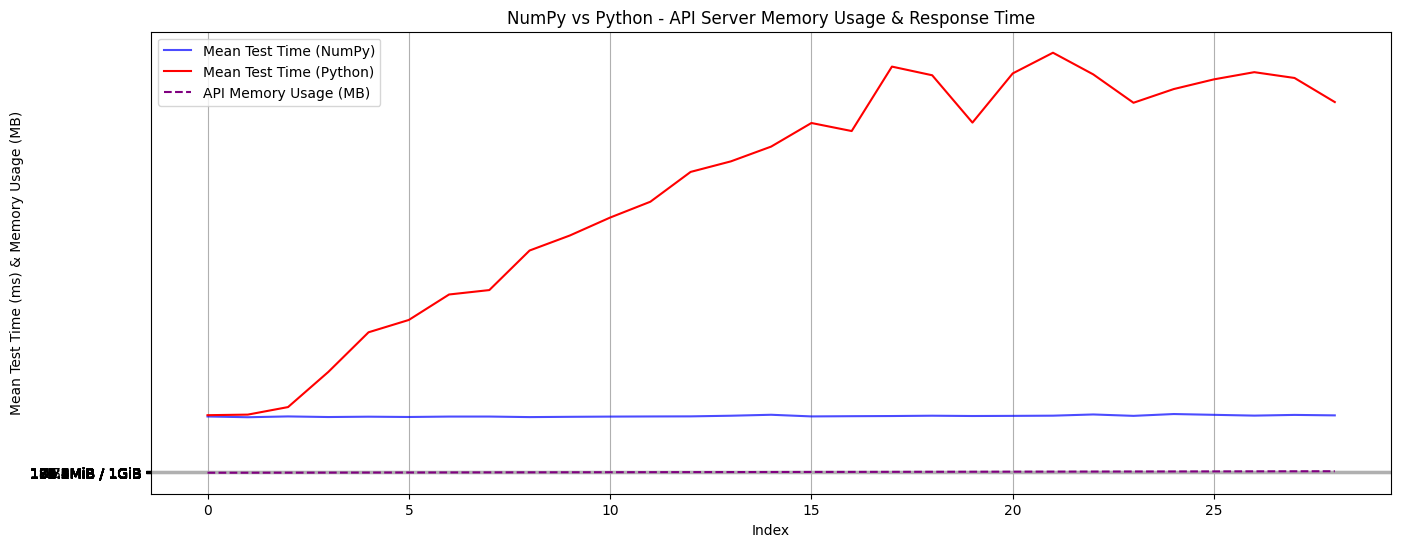

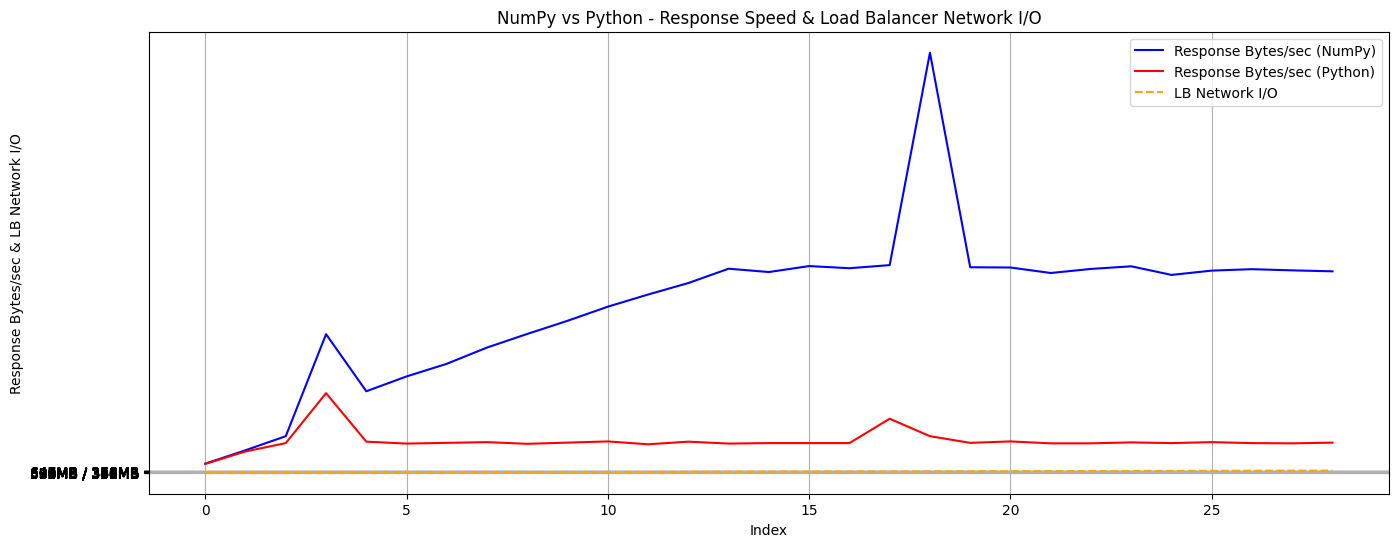

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 📂 File Paths
numpy_perf_file = "nump_440.csv"  
python_perf_file = "cho_440.csv"  
docker_numpy_file = "ds_num_440.csv"  
docker_python_file = "ds_cho_440.csv"  

# 📌 Load Data
df_numpy_perf = pd.read_csv(numpy_perf_file)
df_python_perf = pd.read_csv(python_perf_file)
df_docker_numpy = pd.read_csv(docker_numpy_file)
df_docker_python = pd.read_csv(docker_python_file)

# ✅ Convert column names to lowercase & remove spaces (prevent KeyError)
df_numpy_perf.columns = df_numpy_perf.columns.str.lower().str.strip()
df_python_perf.columns = df_python_perf.columns.str.lower().str.strip()
df_docker_numpy.columns = df_docker_numpy.columns.str.lower().str.strip()
df_docker_python.columns = df_docker_python.columns.str.lower().str.strip()

# ✅ Rename columns (remove timestamp, keep indices)
df_numpy_perf.rename(columns={'datetime': 'timestamp'}, inplace=True)
df_python_perf.rename(columns={'datetime': 'timestamp'}, inplace=True)

df_docker_numpy.rename(columns={'timestamp': 'timestamp', 'cpuperc': 'cpu%', 'memusage': 'memory usage', 'netio': 'network i/o'}, inplace=True)
df_docker_python.rename(columns={'timestamp': 'timestamp', 'cpuperc': 'cpu%', 'memusage': 'memory usage', 'netio': 'network i/o'}, inplace=True)

# ✅ Filter only API server container data
df_docker_numpy = df_docker_numpy[df_docker_numpy["name"] == "reverse-proxy-api-1"]
df_docker_python = df_docker_python[df_docker_python["name"] == "reverse-proxy-api-1"]

# ✅ Match data length (truncate to shortest length)
min_length = min(len(df_numpy_perf), len(df_docker_numpy))
df_numpy_perf = df_numpy_perf.iloc[:min_length].reset_index(drop=True)
df_docker_numpy = df_docker_numpy.iloc[:min_length].reset_index(drop=True)

min_length = min(len(df_python_perf), len(df_docker_python))
df_python_perf = df_python_perf.iloc[:min_length].reset_index(drop=True)
df_docker_python = df_docker_python.iloc[:min_length].reset_index(drop=True)

# 🛠️ Merge without timestamp (1:1 mapping using index)
df_numpy_combined = pd.concat([df_numpy_perf, df_docker_numpy], axis=1)
df_python_combined = pd.concat([df_python_perf, df_docker_python], axis=1)

# ✅ Check merged data
print("NumPy Data:", df_numpy_combined.head())
print("Python Data:", df_python_combined.head())

# 🛠️ Key Columns
y_column_1 = "mean_test_time_(ms)"  # Mean response time
y_column_2 = "tps"  # Transactions per second
y_column_3 = "response_bytes_per_second"  # Response speed

docker_cpu_col = "cpu%"  # CPU Usage
docker_memory_col = "memory usage"  # Memory Usage
docker_net_io_col = "network i/o"  # Network I/O

# 📊 1️⃣ API Server CPU vs TPS
plt.figure(figsize=(16, 6))
plt.plot(df_numpy_combined.index, df_numpy_combined[y_column_2], label="TPS (NumPy)", color='blue', linestyle='-', alpha=0.7)
plt.plot(df_python_combined.index, df_python_combined[y_column_2], label="TPS (Python)", color='red', linestyle='-')
plt.plot(df_numpy_combined.index, df_numpy_combined[docker_cpu_col], label="API CPU Usage (%)", color='green', linestyle='--')
plt.xlabel("Index")
plt.ylabel("TPS & CPU Usage (%)")
plt.title("NumPy vs Python - API Server CPU Usage & TPS Comparison")
plt.legend()
plt.grid(True)
plt.show()

# 📊 2️⃣ API Server Memory Usage vs Response Time
plt.figure(figsize=(16, 6))
plt.plot(df_numpy_combined.index, df_numpy_combined[y_column_1], label="Mean Test Time (NumPy)", color='blue', linestyle='-', alpha=0.7)
plt.plot(df_python_combined.index, df_python_combined[y_column_1], label="Mean Test Time (Python)", color='red', linestyle='-')
plt.plot(df_numpy_combined.index, df_numpy_combined[docker_memory_col], label="API Memory Usage (MB)", color='purple', linestyle='--')
plt.xlabel("Index")
plt.ylabel("Mean Test Time (ms) & Memory Usage (MB)")
plt.title("NumPy vs Python - API Server Memory Usage & Response Time")
plt.legend()
plt.grid(True)
plt.show()

# 📊 3️⃣ Load Balancer Network I/O vs Response Speed
plt.figure(figsize=(16, 6))
plt.plot(df_numpy_combined.index, df_numpy_combined[y_column_3], label="Response Bytes/sec (NumPy)", color='blue', linestyle='-')
plt.plot(df_python_combined.index, df_python_combined[y_column_3], label="Response Bytes/sec (Python)", color='red', linestyle='-')
plt.plot(df_numpy_combined.index, df_numpy_combined[docker_net_io_col], label="LB Network I/O", color='orange', linestyle='--')
plt.xlabel("Index")
plt.ylabel("Response Bytes/sec & LB Network I/O")
plt.title("NumPy vs Python - Response Speed & Load Balancer Network I/O")
plt.legend()
plt.grid(True)
plt.show()


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 📂 File Paths
numpy_perf_file = "nump_440.csv"  
python_perf_file = "cho_440.csv"  
docker_numpy_file = "ds_num_440.csv"  
docker_python_file = "ds_cho_440.csv"  

# 📌 Load Data
df_numpy_perf = pd.read_csv(numpy_perf_file)
df_python_perf = pd.read_csv(python_perf_file)
df_docker_numpy = pd.read_csv(docker_numpy_file)
df_docker_python = pd.read_csv(docker_python_file)

# ✅ Convert column names to lowercase & remove spaces
df_numpy_perf.columns = df_numpy_perf.columns.str.lower().str.strip()
df_python_perf.columns = df_python_perf.columns.str.lower().str.strip()
df_docker_numpy.columns = df_docker_numpy.columns.str.lower().str.strip()
df_docker_python.columns = df_docker_python.columns.str.lower().str.strip()

# ✅ Rename timestamp column for consistency
df_numpy_perf.rename(columns={'datetime': 'timestamp'}, inplace=True)
df_python_perf.rename(columns={'datetime': 'timestamp'}, inplace=True)

df_docker_numpy.rename(columns={'timestamp': 'timestamp', 'cpuperc': 'cpu%', 'memusage': 'memory usage', 'netio': 'network i/o'}, inplace=True)
df_docker_python.rename(columns={'timestamp': 'timestamp', 'cpuperc': 'cpu%', 'memusage': 'memory usage', 'netio': 'network i/o'}, inplace=True)

# ✅ Convert UNIX timestamp to `YYYY-MM-DD HH:MM:SS` format
df_docker_numpy['timestamp'] = pd.to_datetime(df_docker_numpy['timestamp'], unit='s')
df_docker_python['timestamp'] = pd.to_datetime(df_docker_python['timestamp'], unit='s')

# ✅ Filter only API server container data
df_docker_numpy = df_docker_numpy[df_docker_numpy["name"] == "reverse-proxy-api-1"]
df_docker_python = df_docker_python[df_docker_python["name"] == "reverse-proxy-api-1"]

# ✅ Match data length (truncate to shortest length)
min_length = min(len(df_numpy_perf), len(df_docker_numpy))
df_numpy_perf = df_numpy_perf.iloc[:min_length].reset_index(drop=True)
df_docker_numpy = df_docker_numpy.iloc[:min_length].reset_index(drop=True)

min_length = min(len(df_python_perf), len(df_docker_python))
df_python_perf = df_python_perf.iloc[:min_length].reset_index(drop=True)
df_docker_python = df_docker_python.iloc[:min_length].reset_index(drop=True)

# 🛠️ Merge on timestamp (nearest join)
df_numpy_combined = pd.merge_asof(df_numpy_perf.sort_values('timestamp'),
                                  df_docker_numpy.sort_values('timestamp'),
                                  on='timestamp')

df_python_combined = pd.merge_asof(df_python_perf.sort_values('timestamp'),
                                   df_docker_python.sort_values('timestamp'),
                                   on='timestamp')

# ✅ Check merged data
print("NumPy Data:", df_numpy_combined.head())
print("Python Data:", df_python_combined.head())

# 🛠️ Key Columns
y_column_1 = "mean_test_time_(ms)"  # Mean response time
y_column_2 = "tps"  # Transactions per second
y_column_3 = "response_bytes_per_second"  # Response speed

docker_cpu_col = "cpu%"  # CPU Usage
docker_memory_col = "memory usage"  # Memory Usage
docker_net_io_col = "network i/o"  # Network I/O

# 📊 1️⃣ API Server CPU vs TPS
plt.figure(figsize=(16, 6))
plt.plot(df_numpy_combined["timestamp"], df_numpy_combined[y_column_2], label="TPS (NumPy)", color='blue', linestyle='-', alpha=0.7)
plt.plot(df_python_combined["timestamp"], df_python_combined[y_column_2], label="TPS (Python)", color='red', linestyle='-')
plt.plot(df_numpy_combined["timestamp"], df_numpy_combined[docker_cpu_col], label="API CPU Usage (%)", color='green', linestyle='--')
plt.xlabel("Time")
plt.ylabel("TPS & CPU Usage (%)")
plt.title("NumPy vs Python - API Server CPU Usage & TPS Comparison")
plt.legend()
plt.grid(True)
plt.show()

# 📊 2️⃣ API Server Memory Usage vs Response Time
plt.figure(figsize=(16, 6))
plt.plot(df_numpy_combined["timestamp"], df_numpy_combined[y_column_1], label="Mean Test Time (NumPy)", color='blue', linestyle='-', alpha=0.7)
plt.plot(df_python_combined["timestamp"], df_python_combined[y_column_1], label="Mean Test Time (Python)", color='red', linestyle='-')
plt.plot(df_numpy_combined["timestamp"], df_numpy_combined[docker_memory_col], label="API Memory Usage (MB)", color='purple', linestyle='--')
plt.xlabel("Time")
plt.ylabel("Mean Test Time (ms) & Memory Usage (MB)")
plt.title("NumPy vs Python - API Server Memory Usage & Response Time")
plt.legend()
plt.grid(True)
plt.show()

# 📊 3️⃣ Load Balancer Network I/O vs Response Speed
plt.figure(figsize=(16, 6))
plt.plot(df_numpy_combined["timestamp"], df_numpy_combined[y_column_3], label="Response Bytes/sec (NumPy)", color='blue', linestyle='-')
plt.plot(df_python_combined["timestamp"], df_python_combined[y_column_3], label="Response Bytes/sec (Python)", color='red', linestyle='-')
plt.plot(df_numpy_combined["timestamp"], df_numpy_combined[docker_net_io_col], label="LB Network I/O", color='orange', linestyle='--')
plt.xlabel("Time")
plt.ylabel("Response Bytes/sec & LB Network I/O")
plt.title("NumPy vs Python - Response Speed & Load Balancer Network I/O")
plt.legend()
plt.grid(True)
plt.show()


MergeError: Incompatible merge dtype, dtype('<M8[ns]') and dtype('O'), both sides must have numeric dtype

/tmp/ipykernel_2341/1888227651.py:45: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_numpy_combined.fillna(method="ffill", inplace=True)  # Forward fill missing values
/tmp/ipykernel_2341/1888227651.py:46: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_python_combined.fillna(method="ffill", inplace=True)


NumPy Data:             timestamp  vuser  tests  errors  mean_test_time_(ms)  \
0 2025-02-28 07:03:18     41     38       0             1014.500   
1 2025-02-28 07:03:20     71     94       0             1000.904   
2 2025-02-28 07:03:22    101    153       0             1015.444   
3 2025-02-28 07:03:24    149    580       0             1004.562   
4 2025-02-28 07:03:26    188    341       0             1010.663   

   test_time_standard_deviation_(ms)    tps  mean_response_length  \
0                             67.961   19.0                     6   
1                             64.443   47.0                     6   
2                             64.455   76.5                     6   
3                             66.761  290.0                     6   
4                             68.195  170.5                     6   

   response_bytes_per_second  response_errors  ...  mean_time_to_first_byte  \
0                        114                0  ...                   12.000   
1     

TypeError: 'value' must be an instance of str or bytes, not a float

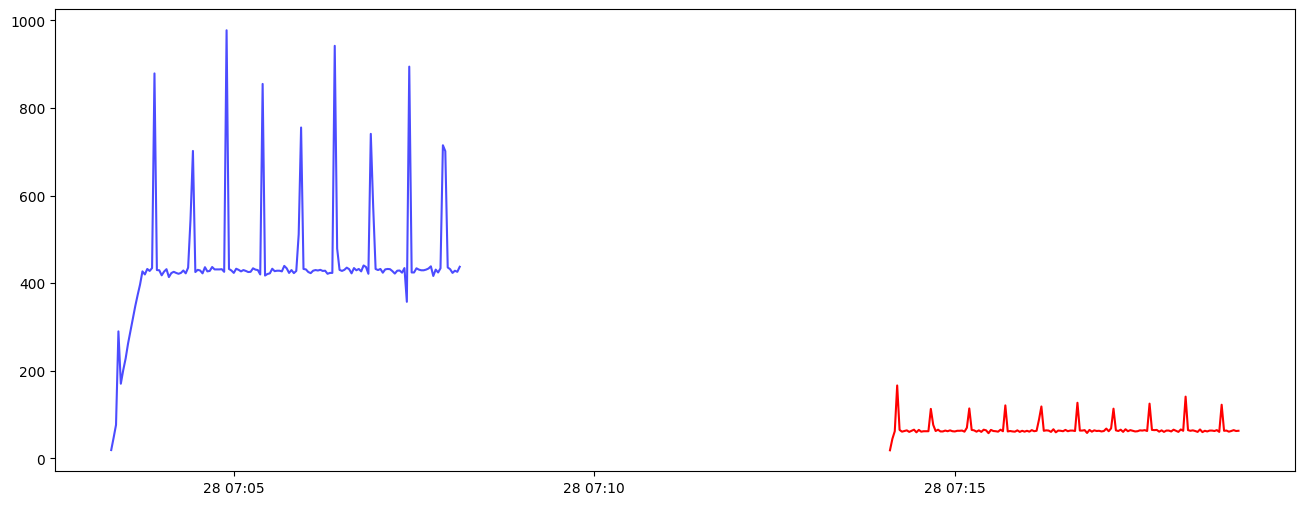

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 📂 File Paths
numpy_perf_file = "nump_440.csv"  
python_perf_file = "cho_440.csv"  
docker_numpy_file = "ds_num_440.csv"  
docker_python_file = "ds_cho_440.csv"  

# 📌 Load Data
df_numpy_perf = pd.read_csv(numpy_perf_file)
df_python_perf = pd.read_csv(python_perf_file)
df_docker_numpy = pd.read_csv(docker_numpy_file)
df_docker_python = pd.read_csv(docker_python_file)

# ✅ Convert column names to lowercase & remove spaces
df_numpy_perf.columns = df_numpy_perf.columns.str.lower().str.strip()
df_python_perf.columns = df_python_perf.columns.str.lower().str.strip()
df_docker_numpy.columns = df_docker_numpy.columns.str.lower().str.strip()
df_docker_python.columns = df_docker_python.columns.str.lower().str.strip()

# ✅ Rename timestamp column for consistency
df_numpy_perf.rename(columns={'datetime': 'timestamp'}, inplace=True)
df_python_perf.rename(columns={'datetime': 'timestamp'}, inplace=True)

df_docker_numpy.rename(columns={'timestamp': 'timestamp', 'cpuperc': 'cpu%', 'memusage': 'memory usage', 'netio': 'network i/o'}, inplace=True)
df_docker_python.rename(columns={'timestamp': 'timestamp', 'cpuperc': 'cpu%', 'memusage': 'memory usage', 'netio': 'network i/o'}, inplace=True)

# ✅ Convert UNIX timestamp to `YYYY-MM-DD HH:MM:SS` format
df_docker_numpy['timestamp'] = pd.to_datetime(df_docker_numpy['timestamp'], unit='s')
df_docker_python['timestamp'] = pd.to_datetime(df_docker_python['timestamp'], unit='s')
df_numpy_perf['timestamp'] = pd.to_datetime(df_numpy_perf['timestamp'])
df_python_perf['timestamp'] = pd.to_datetime(df_python_perf['timestamp'])

# ✅ Filter only API server container data
df_docker_numpy = df_docker_numpy[df_docker_numpy["name"] == "reverse-proxy-api-1"]
df_docker_python = df_docker_python[df_docker_python["name"] == "reverse-proxy-api-1"]

# 🛠️ Left Join (Match nump_440.csv's timestamp)
df_numpy_combined = df_numpy_perf.merge(df_docker_numpy, on="timestamp", how="left")
df_python_combined = df_python_perf.merge(df_docker_python, on="timestamp", how="left")

# ✅ Fill missing values (optional)
df_numpy_combined.fillna(method="ffill", inplace=True)  # Forward fill missing values
df_python_combined.fillna(method="ffill", inplace=True)

# ✅ Check merged data
print("NumPy Data:", df_numpy_combined.head())
print("Python Data:", df_python_combined.head())

# 🛠️ Key Columns
y_column_1 = "mean_test_time_(ms)"  # Mean response time
y_column_2 = "tps"  # Transactions per second
y_column_3 = "response_bytes_per_second"  # Response speed

docker_cpu_col = "cpu%"  # CPU Usage
docker_memory_col = "memory usage"  # Memory Usage
docker_net_io_col = "network i/o"  # Network I/O

# 📊 1️⃣ API Server CPU vs TPS
plt.figure(figsize=(16, 6))
plt.plot(df_numpy_combined["timestamp"], df_numpy_combined[y_column_2], label="TPS (NumPy)", color='blue', linestyle='-', alpha=0.7)
plt.plot(df_python_combined["timestamp"], df_python_combined[y_column_2], label="TPS (Python)", color='red', linestyle='-')
plt.plot(df_numpy_combined["timestamp"], df_numpy_combined[docker_cpu_col], label="API CPU Usage (%)", color='green', linestyle='--')
plt.xlabel("Time")
plt.ylabel("TPS & CPU Usage (%)")
plt.title("NumPy vs Python - API Server CPU Usage & TPS Comparison")
plt.legend()
plt.grid(True)
plt.show()

# 📊 2️⃣ API Server Memory Usage vs Response Time
plt.figure(figsize=(16, 6))
plt.plot(df_numpy_combined["timestamp"], df_numpy_combined[y_column_1], label="Mean Test Time (NumPy)", color='blue', linestyle='-', alpha=0.7)
plt.plot(df_python_combined["timestamp"], df_python_combined[y_column_1], label="Mean Test Time (Python)", color='red', linestyle='-')
plt.plot(df_numpy_combined["timestamp"], df_numpy_combined[docker_memory_col], label="API Memory Usage (MB)", color='purple', linestyle='--')
plt.xlabel("Time")
plt.ylabel("Mean Test Time (ms) & Memory Usage (MB)")
plt.title("NumPy vs Python - API Server Memory Usage & Response Time")
plt.legend()
plt.grid(True)
plt.show()

# 📊 3️⃣ Load Balancer Network I/O vs Response Speed
plt.figure(figsize=(16, 6))
plt.plot(df_numpy_combined["timestamp"], df_numpy_combined[y_column_3], label="Response Bytes/sec (NumPy)", color='blue', linestyle='-')
plt.plot(df_python_combined["timestamp"], df_python_combined[y_column_3], label="Response Bytes/sec (Python)", color='red', linestyle='-')
plt.plot(df_numpy_combined["timestamp"], df_numpy_combined[docker_net_io_col], label="LB Network I/O", color='orange', linestyle='--')
plt.xlabel("Time")
plt.ylabel("Response Bytes/sec & LB Network I/O")
plt.title("NumPy vs Python - Response Speed & Load Balancer Network I/O")
plt.legend()
plt.grid(True)
plt.show()
